Import the cleaned data file:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pickle

DATA_SPLIT_PATH = 'Enter your data split path here'

with open(DATA_SPLIT_PATH, "rb") as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

print("Loaded!", len(X_train), "training samples")

Mounted at /content/drive
Loaded! 180264 training samples


Load the emojis into a list:

In [ ]:
EMOJI_PATH = 'Enter your emoji.txt path'
with open("/content/drive/My Drive/emoji.txt", "r") as f:
    emojis = [e.strip() for e in f.readlines()]

Looking at the cleaned data, each emoji appears many times. We can create a bar graph to display how often each distinct emoji is used.

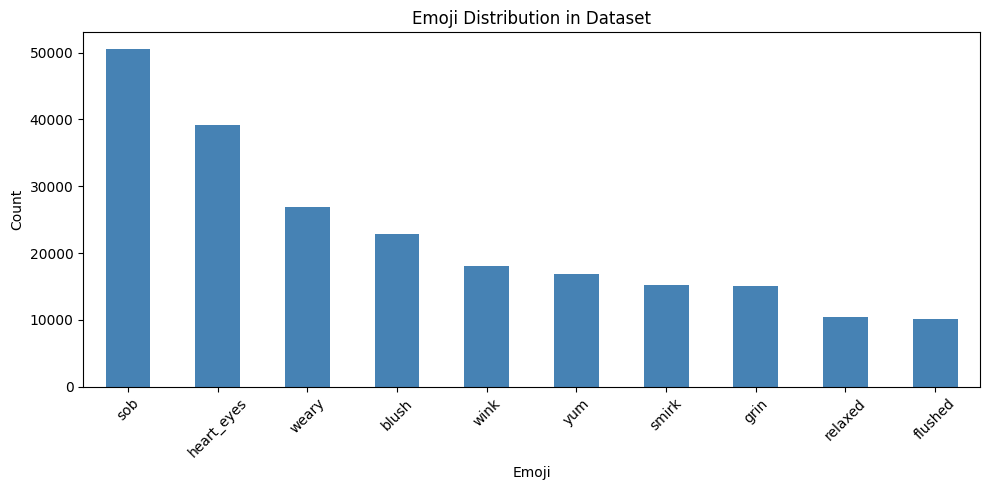

sob           50525
heart_eyes    39193
weary         26855
blush         22894
wink          18078
yum           16790
smirk         15231
grin          15138
relaxed       10472
flushed       10155
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Count each emoji
emoji_counts = pd.Series(emojis).value_counts()

# Plot it
plt.figure(figsize=(10, 5))
emoji_counts.plot(kind='bar', color='steelblue')
plt.title('Emoji Distribution in Dataset')
plt.xlabel('Emoji')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(emoji_counts)

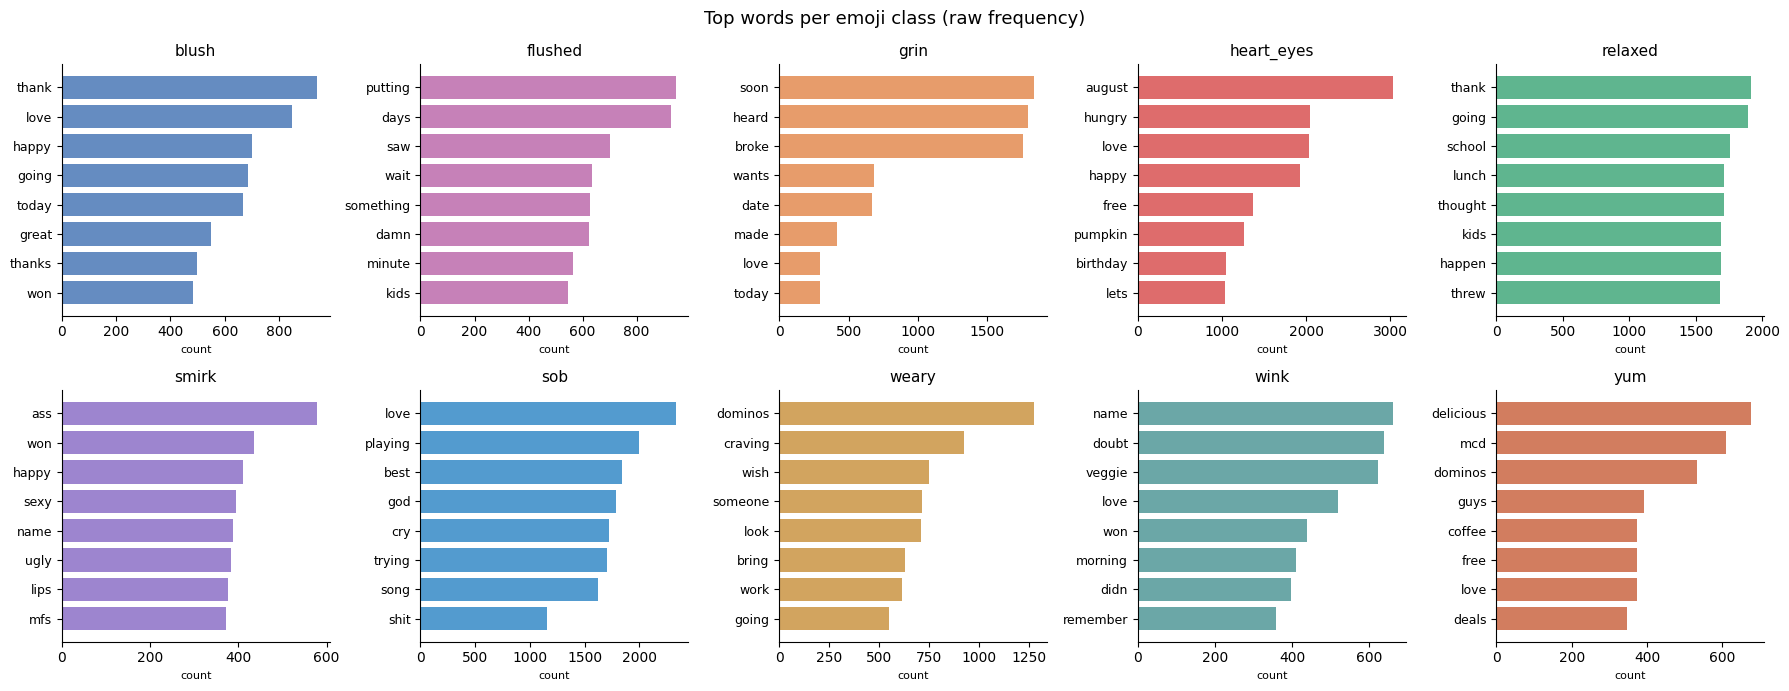

In [ ]:
import re
from collections import defaultdict, Counter

# extracting stop and incredibly common words, add no value or distinction
STOPWORDS = set(["the","a","an","and","or","but","in","on","at","to","for","of","with",
    "is","it","its","this","that","was","are","be","been","have","has","had","do","did",
    "not","no","so","if","as","by","from","up","about","into","then","than","too","very",
    "just","can","will","would","could","should","may","might","we","you","he","she",
    "they","them","their","our","your","his","her","what","which","who","when","where",
    "why","how","all","more","also","there","here","out","get","got","go","im","dont",
    "cant","ive","youre","theyre","am","us","rt","amp","like","know","want","need",
    "gonna","gotta","one","still","even","really","now","back","time","think","make",
    "good","see","day","come","let","way","people","never","always","lol","omg","yeah",
    "okay","hey","oh","wow","lmao","some","much","well","me","my","him","over","after",
    "before","because","when","while","though","through","both","each","most","other",
    "same","such","must","down","first","last","long","little","own","right","big",
    "high","every","next","many","tell","told","say","says","said","ask","give","take",
    "bet","starbucks","subway","walmart","mcdonalds","these","only","don","being","new"])

def tokenize(text):
    tokens = re.findall(r"[a-z]+", text.lower())
    return [w for w in tokens if w not in STOPWORDS and 3 <= len(w) <= 12]

words_by_label = defaultdict(list)
for text, label in zip(X_train + X_test, y_train + y_test):
    words_by_label[label].extend(tokenize(text))

unique_labels = sorted(words_by_label.keys())
top_n = 8
results = {l: Counter(words_by_label[l]).most_common(top_n) for l in unique_labels}

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
colors = ['#3266ad','#b457a0','#e07b3a','#d43b3b','#2a9d6a',
          '#7c5cbf','#1a7abf','#c4862a','#3a8a8a','#c4522a']

# plotting each emoji class graph
for ax, label, color in zip(axes, unique_labels, colors):
    words  = [w for w, c in results[label]][::-1]
    counts = [c for w, c in results[label]][::-1]
    ax.barh(words, counts, color=color, alpha=0.75)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("count", fontsize=8)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("Top words per emoji class (raw frequency)", fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8275/3382026746.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


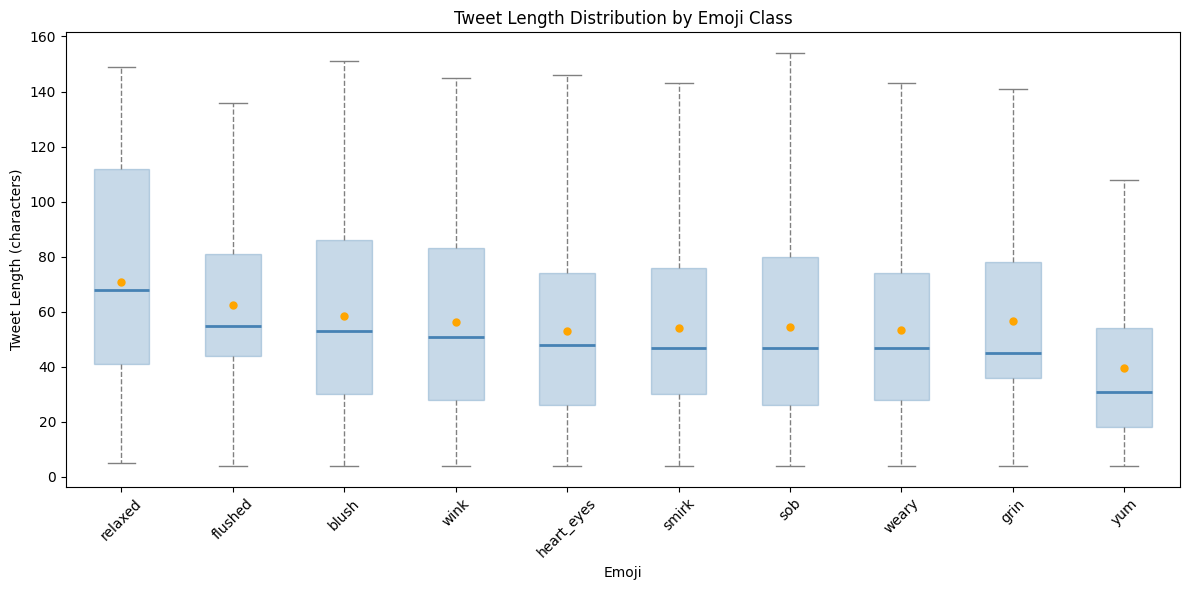

In [ ]:
from collections import defaultdict
import numpy as np

# Group tweet lengths by label
lengths_by_label = defaultdict(list)
for text, label in zip(X_train + X_test, y_train + y_test):
    lengths_by_label[label].append(len(text))

# Sort labels by median tweet length
sorted_labels = sorted(lengths_by_label.keys(),
                       key=lambda l: np.median(lengths_by_label[l]),
                       reverse=True)

# Plot
plt.figure(figsize=(12, 6))
plt.boxplot(
    [lengths_by_label[l] for l in sorted_labels],
    labels=sorted_labels,
    showfliers=False,
    showmeans=True,
    patch_artist=True,
    meanprops=dict(marker="o", markerfacecolor="orange", markeredgecolor="orange", markersize=5),
    medianprops=dict(color="steelblue", linewidth=2),
    boxprops=dict(facecolor="steelblue", alpha=0.3, color="steelblue"),
    whiskerprops=dict(color="gray", linestyle="--"),
    capprops=dict(color="gray"),
)

plt.title("Tweet Length Distribution by Emoji Class")
plt.xlabel("Emoji")
plt.ylabel("Tweet Length (characters)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()